In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from tensorflow.keras.datasets import mnist
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# 1. Load Data (Same as before)
(train_images, train_labels), (_, _) = mnist.load_data()

# 2. Preprocessing (CRITICAL CHANGE HERE)
# DCGAN Generator uses Tanh activation, which outputs [-1, 1].
# therefore, must scale real images to [-1, 1] to match.
# Formula: (Image - 127.5) / 127.5
X_train = (train_images - 127.5) / 127.5
X_train = torch.tensor(X_train, dtype=torch.float32)

# Add channel dimension (N, 28, 28) -> (N, 1, 28, 28)
X_train = X_train.unsqueeze(1)
# don't strictly need labels for GANs (unsupervised), but the loader expects them
y_train = torch.tensor(train_labels, dtype=torch.long)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Create Dataset and Loader
train_ds = TensorDataset(X_train, y_train)
# Drop_last=True is important! BatchNorm can crash if the last batch is size 1.
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, drop_last=True)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Device: cuda


Input: A random noise vector (Latent Space) of size 100.

Goal: Turn $(100)$ into $(1, 28, 28)$.

How:  use ConvTranspose2d.bascially a reverse conv. or Upsampling layer. It takes a pixel and "splats" it out into a larger grid.

In [2]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()
        self.latent_dim = latent_dim
        
        # want to project the noise into a volume of (128 channels x 7 x 7 pixels)
        # 128 * 7 * 7 = 6272
        # so we need a linear layer that takes in the latent_dim and outputs 6272 features
        self.fc = nn.Linear(latent_dim, 128 * 7 * 7)
        self.bn1 = nn.BatchNorm1d(128 * 7 * 7)
        
        # Upsampling layers: ConvTranspose2d
        # Block 1: 7x7 -> 14x14
        # kernel_size=4, stride=2, padding=1 is the standard "double the size" recipe
        self.trans_conv1 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(64) # Batch norm on 2D maps
        # Block 2: 14x14 -> 28x28
        # Output is 1 channel (grayscale)
        self.trans_conv2 = nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1)
        
    def forward(self, z):
        x = self.fc(z)
        x = self.bn1(x)
        x = torch.relu(x)
        # Reshape flat vector into 3D feature map (Batch, 128, 7, 7)
        x = x.view(-1, 128, 7, 7)
        
        # 2. Upsample to 14x14
        x = self.trans_conv1(x)
        x = self.bn2(x)
        x = torch.relu(x)
        
        # 3. Upsample to 28x28 (Final Layer)
        x = self.trans_conv2(x)
        
        # OUTPUT ACTIVATION: Tanh
        # Forces values to be between [-1, 1], matching  image normalization.
        x = torch.tanh(x) 
        
        return x

In [3]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        
        # Block 1: 28x28 -> 14x14
        # Stride=2 cuts size in half
        self.conv1 = nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1)
        
        # Block 2: 14x14 -> 7x7
        self.conv2 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        
        # Output Block: Flatten -> Single Probability
        # Input size is 128 channels * 7 * 7 pixels
        self.fc = nn.Linear(128 * 7 * 7, 1)
        
    def forward(self, img):
        # img shape: (Batch, 1, 28, 28)
        
        # Layer 1
        x = self.conv1(img)
        # Activation: LeakyReLU (slope 0.2)
        # Allows gradients to flow even when the neuron is negative (vital for GANs)
        x = torch.nn.functional.leaky_relu(x, 0.2)
        
        # Layer 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = torch.nn.functional.leaky_relu(x, 0.2)
        
        # Flatten
        x = x.view(-1, 128 * 7 * 7)
        
        # Output
        x = self.fc(x)
        # Sigmoid turns the raw number into a probability [0, 1]
        x = torch.sigmoid(x)
        
        return x

In [4]:
# Initialize
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# Loss function: Binary Cross Entropy
# We are classifying Real (1) vs Fake (0)
criterion = nn.BCELoss()

# Optimizers
# Adam is standard for GANs. lr=0.0002 is a "magic number" from the DCGAN paper.
# beatas=(0.5, 0.999) is also from the paper, helps stabilize training. 
# (beta is the exponential decay rate for the moment estimates in Adam)
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

Training started at: 2026-02-11 02:56:55
Epoch [  1/50] | Loss_D: 0.3921 | Loss_G: 2.5789 | Time: 5.34s


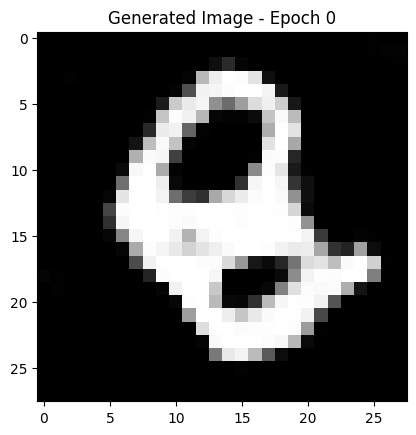

Epoch [  2/50] | Loss_D: 0.3987 | Loss_G: 2.6004 | Time: 5.38s
Epoch [  3/50] | Loss_D: 0.3762 | Loss_G: 2.6581 | Time: 5.33s
Epoch [  4/50] | Loss_D: 0.3647 | Loss_G: 2.7249 | Time: 5.42s
Epoch [  5/50] | Loss_D: 0.4023 | Loss_G: 2.6941 | Time: 5.43s
Epoch [  6/50] | Loss_D: 0.3636 | Loss_G: 2.7775 | Time: 5.42s
Epoch [  7/50] | Loss_D: 0.3479 | Loss_G: 2.8332 | Time: 5.53s
Epoch [  8/50] | Loss_D: 0.3512 | Loss_G: 2.8763 | Time: 5.49s
Epoch [  9/50] | Loss_D: 0.3588 | Loss_G: 2.8979 | Time: 5.61s
Epoch [ 10/50] | Loss_D: 0.3369 | Loss_G: 2.9201 | Time: 5.56s
Epoch [ 11/50] | Loss_D: 0.3561 | Loss_G: 2.9650 | Time: 5.67s


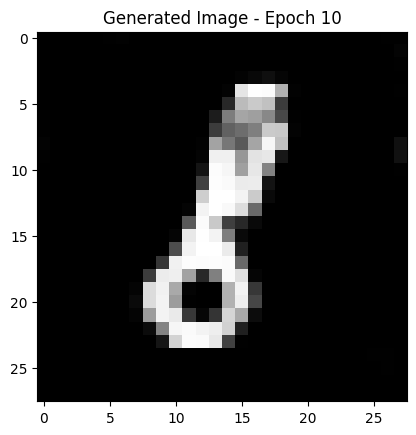

Epoch [ 12/50] | Loss_D: 0.3420 | Loss_G: 2.9697 | Time: 5.63s
Epoch [ 13/50] | Loss_D: 0.3357 | Loss_G: 3.0348 | Time: 5.72s
Epoch [ 14/50] | Loss_D: 0.3579 | Loss_G: 3.0457 | Time: 5.66s
Epoch [ 15/50] | Loss_D: 0.3173 | Loss_G: 3.0371 | Time: 5.77s
Epoch [ 16/50] | Loss_D: 0.3335 | Loss_G: 3.0951 | Time: 5.69s
Epoch [ 17/50] | Loss_D: 0.3124 | Loss_G: 3.1507 | Time: 5.73s
Epoch [ 18/50] | Loss_D: 0.3730 | Loss_G: 3.0514 | Time: 5.68s
Epoch [ 19/50] | Loss_D: 0.2946 | Loss_G: 3.1818 | Time: 5.74s
Epoch [ 20/50] | Loss_D: 0.3158 | Loss_G: 3.2159 | Time: 5.66s
Epoch [ 21/50] | Loss_D: 0.3002 | Loss_G: 3.2269 | Time: 5.72s


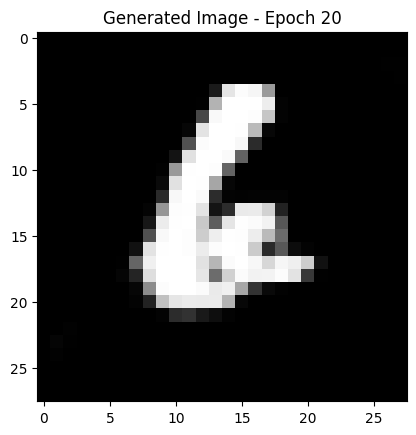

Epoch [ 22/50] | Loss_D: 0.3448 | Loss_G: 3.1752 | Time: 5.63s
Epoch [ 23/50] | Loss_D: 0.3171 | Loss_G: 3.2346 | Time: 5.69s
Epoch [ 24/50] | Loss_D: 0.3017 | Loss_G: 3.2811 | Time: 5.64s
Epoch [ 25/50] | Loss_D: 0.2903 | Loss_G: 3.3193 | Time: 5.71s
Epoch [ 26/50] | Loss_D: 0.3057 | Loss_G: 3.3297 | Time: 5.64s
Epoch [ 27/50] | Loss_D: 0.3317 | Loss_G: 3.2475 | Time: 5.72s
Epoch [ 28/50] | Loss_D: 0.3316 | Loss_G: 3.3404 | Time: 5.67s
Epoch [ 29/50] | Loss_D: 0.2903 | Loss_G: 3.3134 | Time: 5.71s
Epoch [ 30/50] | Loss_D: 0.2817 | Loss_G: 3.4022 | Time: 5.71s
Epoch [ 31/50] | Loss_D: 0.3110 | Loss_G: 3.3574 | Time: 5.73s


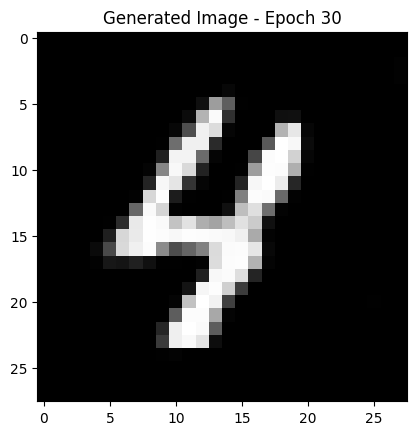

Epoch [ 32/50] | Loss_D: 0.3263 | Loss_G: 3.4223 | Time: 5.72s
Epoch [ 33/50] | Loss_D: 0.2803 | Loss_G: 3.3543 | Time: 5.70s
Epoch [ 34/50] | Loss_D: 0.3119 | Loss_G: 3.4151 | Time: 5.70s
Epoch [ 35/50] | Loss_D: 0.2839 | Loss_G: 3.4077 | Time: 5.68s
Epoch [ 36/50] | Loss_D: 0.2811 | Loss_G: 3.4475 | Time: 5.71s
Epoch [ 37/50] | Loss_D: 0.2993 | Loss_G: 3.4690 | Time: 5.66s
Epoch [ 38/50] | Loss_D: 0.2867 | Loss_G: 3.4605 | Time: 5.71s
Epoch [ 39/50] | Loss_D: 0.2940 | Loss_G: 3.4589 | Time: 5.63s
Epoch [ 40/50] | Loss_D: 0.2979 | Loss_G: 3.4655 | Time: 5.72s
Epoch [ 41/50] | Loss_D: 0.3291 | Loss_G: 3.4012 | Time: 5.63s


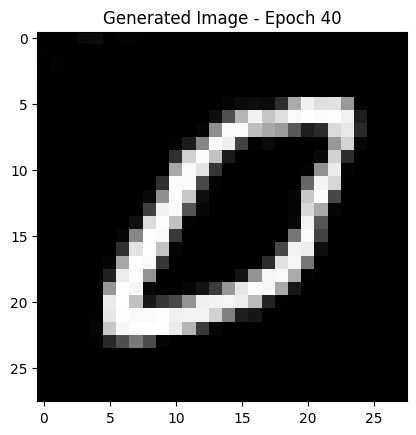

Epoch [ 42/50] | Loss_D: 0.2836 | Loss_G: 3.4738 | Time: 5.72s
Epoch [ 43/50] | Loss_D: 0.2919 | Loss_G: 3.4906 | Time: 5.64s
Epoch [ 44/50] | Loss_D: 0.3291 | Loss_G: 3.4084 | Time: 5.72s
Epoch [ 45/50] | Loss_D: 0.2906 | Loss_G: 3.4689 | Time: 5.66s
Epoch [ 46/50] | Loss_D: 0.2878 | Loss_G: 3.4928 | Time: 5.74s
Epoch [ 47/50] | Loss_D: 0.3458 | Loss_G: 3.4086 | Time: 5.65s
Epoch [ 48/50] | Loss_D: 0.2841 | Loss_G: 3.4989 | Time: 5.74s
Epoch [ 49/50] | Loss_D: 0.3045 | Loss_G: 3.5234 | Time: 5.66s
Epoch [ 50/50] | Loss_D: 0.3236 | Loss_G: 3.4131 | Time: 5.72s
Training completed at: 2026-02-11 03:01:38
Total training time: 282.14s (4.70 minutes)
Average time per epoch: 5.64s


In [6]:
import time
from datetime import datetime

# Training history tracking
history = {
    'loss_d': [],
    'loss_g': [],
    'epoch_times': []
}

epochs = 50
print(f"Training started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 60)

for epoch in range(epochs):
    epoch_start_time = time.time()
    
    epoch_loss_d = 0
    epoch_loss_g = 0
    batch_count = 0
    
    for i, (real_imgs, _) in enumerate(train_loader):
        # Train discrim. on real images
        # ---------------------
        #  1. Train Discriminator
        # ---------------------
        # Goal: Maximize probability of assigning 1 to real images and 0 to fake images.
        
        # Get batch size (might change for last batch)
        batch_size = real_imgs.size(0)
        
        # Create labels
        # Real = 1, Fake = 0
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)
        
        # A. Train on Real Data
        real_imgs = real_imgs.to(device)
        optimizer_D.zero_grad() # Clear gradients
        
        # we show D the real images
        outputs = discriminator(real_imgs) # D predicts on real images
        # D should output values close to 1 for real images, so we compare against real_labels (which are 1s)
        # if D guesses perfectly, outputs will be 1 and loss will be 0. If D is wrong, outputs will be 0 and loss will be high.
        loss_d_real = criterion(outputs, real_labels) # Calculate loss (should be 1)
        loss_d_real.backward() # Compute gradients (D learns and now knows how to classify real images better)
        # B. Train on Fake Data
        # Generate noise
        z = torch.randn(batch_size, 100).to(device)
        fake_imgs = generator(z) # G creates fake images
        
        # Pass fake images to D
        # .detach() is critical! 
        # It tells PyTorch "Don't compute gradients for G during this step"
        outputs = discriminator(fake_imgs.detach()) 
        # D should output values close to 0 for fake images, so we compare against fake_labels (which are 0s)
        loss_d_fake = criterion(outputs, fake_labels) # Calculate loss (this should be 0 if D is perfect)
        loss_d_fake.backward() # Compute gradients (D learns and now knows how to classify fake images better)
        
        # Update Discriminator weights
        optimizer_D.step()
        
        # at this point, only D has been updated. G has not been updated yet.
        # Now D knows how to classify real vs fake better, so we can train G to try to trick D.
        
        # -----------------
        #  2. Train Generator
        # -----------------
        # Goal: Trick the discriminator (make it predict 1 for fake images)
        
        optimizer_G.zero_grad() # reset gradients for G
        
        # D looks at the fake images again (this time we want gradients to flow to G)
        outputs = discriminator(fake_imgs)
        
        # IMPORTANT: We want D to think these are REAL (label=1)
        # This is how G learns to trick D.
        loss_g = criterion(outputs, real_labels)
        
        loss_g.backward() # Compute gradients (G learns to trick D)
        optimizer_G.step()
        
        # Accumulate batch losses
        epoch_loss_d += (loss_d_real + loss_d_fake).item()
        epoch_loss_g += loss_g.item()
        batch_count += 1
    
    # Average losses for the epoch
    avg_loss_d = epoch_loss_d / batch_count
    avg_loss_g = epoch_loss_g / batch_count
    
    # Record to history
    history['loss_d'].append(avg_loss_d)
    history['loss_g'].append(avg_loss_g)
    
    # Time tracking
    epoch_time = time.time() - epoch_start_time
    history['epoch_times'].append(epoch_time)
    
    # Informative printing
    # if epoch % 5 == 0 or epoch == epochs - 1:
    print(f"Epoch [{epoch+1:3d}/{epochs}] | Loss_D: {avg_loss_d:.4f} | Loss_G: {avg_loss_g:.4f} | "
            f"Time: {epoch_time:.2f}s")

    # Optional: Visualize result every 10 epochs
    if epoch % 10 == 0:
        generator.eval()  # Set to evaluation mode
        with torch.no_grad():
            fake_sample = generator(torch.randn(1, 100).to(device)).cpu()
            # Rescale back to [0, 1] for plotting
            fake_sample = (fake_sample + 1) / 2.0 
            plt.imshow(fake_sample[0, 0], cmap='gray')
            plt.title(f"Generated Image - Epoch {epoch}")
            plt.show()
        generator.train()  # Set back to training mode

print("=" * 60)
print(f"Training completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
total_time = sum(history['epoch_times'])
print(f"Total training time: {total_time:.2f}s ({total_time/60:.2f} minutes)")
print(f"Average time per epoch: {total_time/epochs:.2f}s")


TRAINING SUMMARY

Loss Statistics:
  Generator Loss      - Min: 2.5789, Max: 3.5234, Final: 3.4131
  Discriminator Loss  - Min: 0.2803, Max: 0.4023, Final: 0.3236

Timing Statistics:
  Min epoch time: 5.33s
  Max epoch time: 5.77s
  Avg epoch time: 5.64s
  Total epochs: 50
  Total time: 282.14s (4.70 min)

TRAINING PLOTS



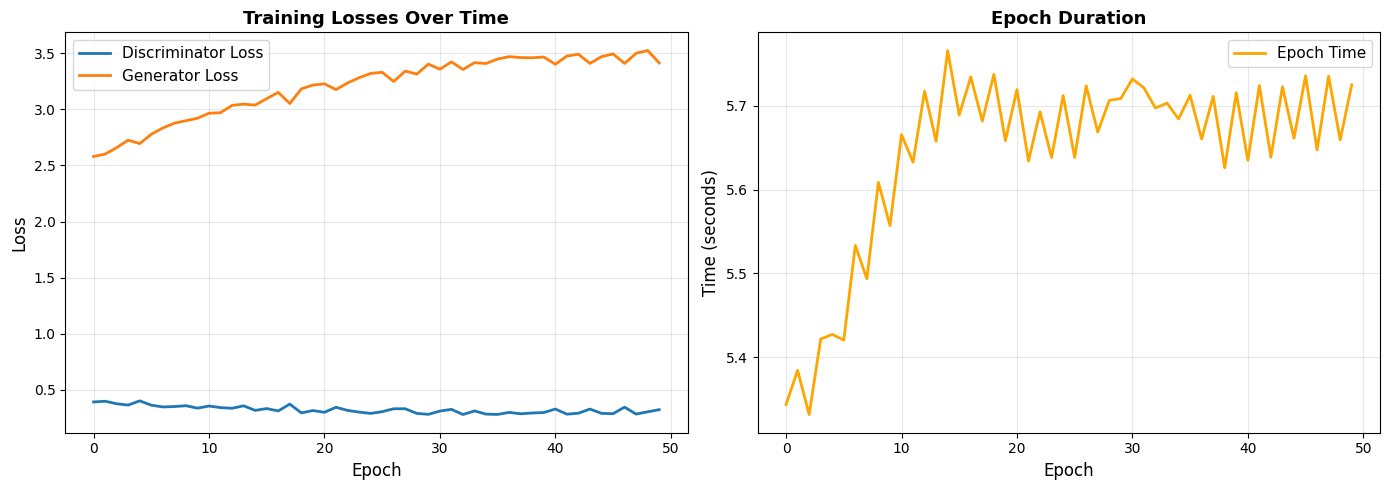

 Training history and plots displayed successfully!
 Model is ready for inference (Generator is trained)


In [7]:
# ==================== Training Summary & Visualization ====================
import numpy as np

print("\n" + "=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)

# Loss statistics
print("\nLoss Statistics:")
print(f"  Generator Loss      - Min: {min(history['loss_g']):.4f}, Max: {max(history['loss_g']):.4f}, "
      f"Final: {history['loss_g'][-1]:.4f}")
print(f"  Discriminator Loss  - Min: {min(history['loss_d']):.4f}, Max: {max(history['loss_d']):.4f}, "
      f"Final: {history['loss_d'][-1]:.4f}")

# Timing statistics
times = history['epoch_times']
print(f"\nTiming Statistics:")
print(f"  Min epoch time: {min(times):.2f}s")
print(f"  Max epoch time: {max(times):.2f}s")
print(f"  Avg epoch time: {np.mean(times):.2f}s")
print(f"  Total epochs: {epochs}")
print(f"  Total time: {sum(times):.2f}s ({sum(times)/60:.2f} min)")

print("\n" + "=" * 60)
print("TRAINING PLOTS")
print("=" * 60 + "\n")

# Plot 1: Loss Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(history['loss_d'], label='Discriminator Loss', linewidth=2)
ax1.plot(history['loss_g'], label='Generator Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training Losses Over Time', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Epoch time plot
ax2.plot(history['epoch_times'], label='Epoch Time', linewidth=2, color='orange')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Time (seconds)', fontsize=12)
ax2.set_title('Epoch Duration', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(" Training history and plots displayed successfully!")
print(" Model is ready for inference (Generator is trained)")


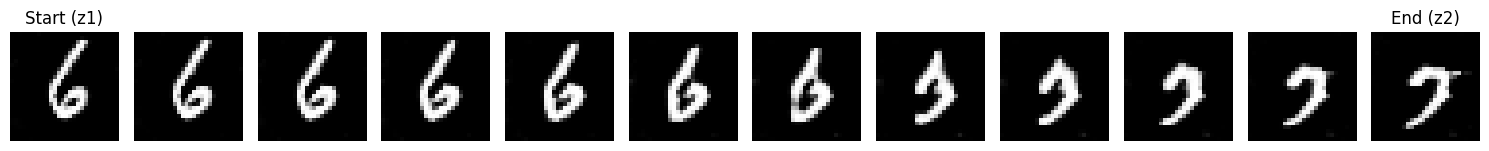

In [15]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# 1. Pick two random points in the latent space
# These represent two random potential digits
z1 = torch.randn(1, 100).to(device)
z2 = torch.randn(1, 100).to(device)
# 2. Define how many steps to morph
steps = 12
alphas = np.linspace(0, 1, steps) # [0.0, 0.1, ... 1.0]

# 3. Create the interpolation vectors
# Formula: z = (1 - alpha) * z1 + alpha * z2
z_interp = []
for alpha in alphas:
    vector = (1 - alpha) * z1 + alpha * z2
    z_interp.append(vector)

# Stack them into a single batch of shape (12, 100)
z_batch = torch.cat(z_interp)

# Stack them into a single batch of shape (12, 100)
z_batch = torch.cat(z_interp)

# 4. Generate images from these interpolated vectors
generator.eval() # Good practice, though batchnorm might behave weirdly on small batches
with torch.no_grad():
    generated_images = generator(z_batch).cpu()

# 5. Plot the result
plt.figure(figsize=(15, 6))
for i in range(steps):
    ax = plt.subplot(1, steps, i + 1)
    
    # Rescale [-1, 1] -> [0, 1]
    img = (generated_images[i].squeeze() + 1) / 2.0
    
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    
    # Label the start and end
    if i == 0:
        ax.set_title("Start (z1)")
    elif i == steps - 1:
        ax.set_title("End (z2)")

plt.tight_layout()
plt.show()